C:\Users\ahmad\AppData\Local\Temp\ipykernel_7700\1413287518.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


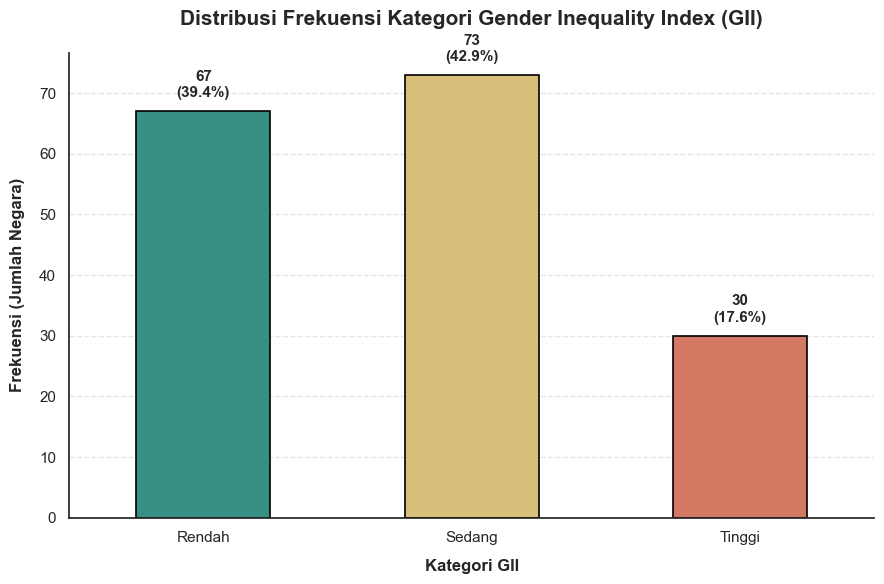

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Konfigurasi visualisasi modern
sns.set_theme(style="white", rc={"axes.facecolor": "#ffffff"})
plt.figure(figsize=(9, 6))

# Membaca data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')
df_clean = df.dropna(subset=['GII']).copy()

# Mengelompokkan data ke dalam 3 kategori
df_clean['Kategori_GII'] = pd.cut(
    df_clean['GII'], 
    bins=3, 
    labels=['Rendah', 'Sedang', 'Tinggi']
)

total_data = len(df_clean)
custom_palette = ['#2a9d8f', '#e9c46a', '#e76f51']

# Membuat countplot
ax = sns.countplot(
    x='Kategori_GII', 
    data=df_clean, 
    order=['Rendah', 'Sedang', 'Tinggi'], 
    palette=custom_palette,
    edgecolor='black',
    linewidth=1.2,
    width=0.5
)

# Menyesuaikan elemen estetika grafik
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Kustomisasi label sumbu
plt.title('Distribusi Frekuensi Kategori Gender Inequality Index (GII)', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Kategori GII', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Frekuensi (Jumlah Negara)', fontsize=12, fontweight='bold', labelpad=10)

# Menambahkan anotasi persentase pada bar
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(height/total_data)*100:.1f}%'
    ax.annotate(f'{int(height)}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                xytext=(0, 8), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
# Menyimpan grafik sesuai penamaan soal
plt.savefig('Soal_4_Distribusi_Frekuensi_GII.png', dpi=300, bbox_inches='tight')